# ForgeWM Paper 2 — Experiment 4: Faithfulness Validation

**Goal**: Validate Lemma 1 — faithfulness holds generically for the elastic-plastic
material system. Show that the PC algorithm on FEM intervention data recovers
the correct causal DAG, and that observational PC fails due to confounding.

## Ground-truth causal DAG
```
E ──────────────────────► σ
ε ──────────────────────► σ
σ_y ────────────────────► σ  (only in plastic regime)
H ──────────────────────► σ  (only in plastic regime)
regime ─────────────────► σ  (mediator: elastic vs plastic)
```
Axiom system A knows: σ = Eε (elastic only). Unknown: plastic regime.

**Expected runtime**: ~2 hours on T4

---

## Cell 1 — Install and Imports

In [8]:
!pip install -q causal-learn pysr scipy scikit-learn matplotlib numpy pandas tqdm

import subprocess
subprocess.run('pip install -q causallearn scipy scikit-learn '
               'matplotlib numpy pandas tqdm networkx', shell=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from tqdm.notebook import tqdm
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings, json
warnings.filterwarnings('ignore')

print('Imports ready.')

Imports ready.


## Cell 2 — FEM Oracle with Exact Interventions

In [9]:
LAMBDA_STAR = 0.002

def constitutive_law(epsilon, E, sigma_y, H):
    """True two-regime constitutive law."""
    if epsilon <= LAMBDA_STAR:
        return E * epsilon
    return sigma_y + H * (epsilon - LAMBDA_STAR)

def fem_observational(n_samples, rng):
    """
    Observational FEM data — no interventions.
    All variables sampled from their natural joint distribution.
    Returns DataFrame with columns: [E, epsilon, sigma_y, H, regime, sigma]
    """
    records = []
    for _ in range(n_samples):
        E        = rng.uniform(100e9, 300e9)
        epsilon  = rng.uniform(0.0005, 0.006)
        sigma_y  = rng.uniform(200e6, 600e6)
        H        = rng.uniform(1e9, 50e9)
        nu       = rng.uniform(0.25, 0.45)
        sigma    = constitutive_law(epsilon, E, sigma_y, H)
        regime   = 1 if epsilon > LAMBDA_STAR else 0
        records.append({'E':E, 'epsilon':epsilon, 'sigma_y':sigma_y,
                        'H':H, 'nu':nu, 'regime':regime, 'sigma':sigma})
    return pd.DataFrame(records)

def fem_interventional(n_samples, rng, do_variable=None, do_value=None):
    """
    Interventional FEM data — exact do(X=x) operation.
    When do_variable is set, that variable is fixed to do_value
    for ALL samples — eliminating all incoming causal paths to it.
    This is the FEM analogue of a perfect randomised experiment.
    """
    records = []
    for _ in range(n_samples):
        E       = rng.uniform(100e9, 300e9)
        epsilon = rng.uniform(0.0005, 0.006)
        sigma_y = rng.uniform(200e6, 600e6)
        H       = rng.uniform(1e9, 50e9)
        nu      = rng.uniform(0.25, 0.45)

        # ── Exact do-operation: override the intervened variable ──────
        # In FEM: Dirichlet BC sets the value exactly,
        # eliminating ALL incoming causal paths to that variable.
        if do_variable == 'E':        E       = do_value
        elif do_variable == 'epsilon': epsilon = do_value
        elif do_variable == 'sigma_y': sigma_y = do_value
        elif do_variable == 'H':       H       = do_value

        sigma  = constitutive_law(epsilon, E, sigma_y, H)
        regime = 1 if epsilon > LAMBDA_STAR else 0
        records.append({'E':E, 'epsilon':epsilon, 'sigma_y':sigma_y,
                        'H':H, 'nu':nu, 'regime':regime, 'sigma':sigma})
    return pd.DataFrame(records)

# ── Verify exact intervention ─────────────────────────────────────────
rng_test = np.random.default_rng(0)
df_obs   = fem_observational(100, rng_test)
df_int   = fem_interventional(100, rng_test, 'E', 200e9)

print('Observational E variance:     ', df_obs['E'].std())
print('Interventional E variance:    ', df_int['E'].std(),
      '(should be 0.0 — exact do-operation)')
print(f'\nFEM oracle ready. λ* = {LAMBDA_STAR}')

Observational E variance:      54025377142.63949
Interventional E variance:     0.0 (should be 0.0 — exact do-operation)

FEM oracle ready. λ* = 0.002


## Cell 3 — PC Algorithm on FEM Data

In [10]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

VARIABLES = ['E', 'epsilon', 'sigma_y', 'H', 'regime', 'sigma']
N_SAMPLES  = 2000
ALPHA      = 0.05

# ── Ground truth DAG ─────────────────────────────────────────────────
# E → sigma, epsilon → sigma, epsilon → regime
# sigma_y → sigma (plastic only, mediated by regime)
# H → sigma (plastic only, mediated by regime)
TRUE_EDGES = {
    ('E',       'sigma'),
    ('epsilon', 'sigma'),
    ('epsilon', 'regime'),
    ('sigma_y', 'sigma'),
    ('H',       'sigma'),
    ('regime',  'sigma'),
}

def run_pc(df, variables, alpha=ALPHA):
    """Run PC algorithm, return adjacency set and CPDAG."""
    data = df[variables].values.astype(float)
    scaler = StandardScaler()
    data_sc = scaler.fit_transform(data)
    cg = pc(data_sc, alpha=alpha, indep_test='fisherz',
            stable=True, uc_rule=0, uc_priority=2,
            verbose=False, show_progress=False)
    # Extract edges from adjacency matrix
    adj = cg.G.graph   # shape (n_vars, n_vars)
    edges = set()
    for i in range(len(variables)):
        for j in range(len(variables)):
            if adj[i, j] != 0:
                edges.add((variables[i], variables[j]))
    return edges, cg

def edge_metrics(recovered, true_edges):
    """Precision, recall, F1 of edge recovery."""
    # Undirected comparison (CPDAG may orient differently)
    def undirected(e): return frozenset(e)
    rec_ud  = {undirected(e) for e in recovered}
    true_ud = {undirected(e) for e in true_edges}
    tp = len(rec_ud & true_ud)
    fp = len(rec_ud - true_ud)
    fn = len(true_ud - rec_ud)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
    return {'precision':prec, 'recall':rec, 'f1':f1,
            'tp':tp, 'fp':fp, 'fn':fn,
            'recovered': rec_ud, 'missed': true_ud - rec_ud,
            'spurious':  rec_ud - true_ud}

print('PC algorithm ready.')
print(f'Variables: {VARIABLES}')
print(f'True edges: {len(TRUE_EDGES)}')

PC algorithm ready.
Variables: ['E', 'epsilon', 'sigma_y', 'H', 'regime', 'sigma']
True edges: 6


## Cell 4 — Condition 1: PC on Observational Data

In [11]:
print('Condition 1: PC on observational data (no interventions) ...')
rng_obs = np.random.default_rng(42)
df_obs  = fem_observational(N_SAMPLES, rng_obs)

edges_obs, cg_obs = run_pc(df_obs, VARIABLES)
metrics_obs       = edge_metrics(edges_obs, TRUE_EDGES)

print(f'\nObservational PC results:')
print(f'  Edges recovered: {len(edges_obs)}')
print(f'  Precision: {metrics_obs["precision"]:.3f}')
print(f'  Recall:    {metrics_obs["recall"]:.3f}')
print(f'  F1:        {metrics_obs["f1"]:.3f}')
print(f'  TP={metrics_obs["tp"]}  FP={metrics_obs["fp"]}  FN={metrics_obs["fn"]}')
if metrics_obs['missed']:
    print(f'  Missed edges: {metrics_obs["missed"]}')
if metrics_obs['spurious']:
    print(f'  Spurious edges: {metrics_obs["spurious"]}')

Condition 1: PC on observational data (no interventions) ...

Observational PC results:
  Edges recovered: 12
  Precision: 1.000
  Recall:    1.000
  F1:        1.000
  TP=6  FP=0  FN=0


## Cell 5 — Condition 2: PC on Interventional Data

In [12]:
print('Condition 2: PC on interventional data (do-operations) ...')
print('Pooling data from 4 intervention conditions ...')

# ── Pool multiple intervention datasets ──────────────────────────────
# Each intervention fixes one variable — eliminates confounding paths
# Standard approach: pool interventional data from multiple do-ops
# to recover the full causal structure

rng_int = np.random.default_rng(42)
dfs_int = []

# Baseline observational
dfs_int.append(fem_observational(500, rng_int))

# do(E = 150 GPa) — low stiffness
dfs_int.append(fem_interventional(375, rng_int, 'E', 150e9))

# do(E = 250 GPa) — high stiffness
dfs_int.append(fem_interventional(375, rng_int, 'E', 250e9))

# do(epsilon = 0.001) — elastic regime forced
dfs_int.append(fem_interventional(375, rng_int, 'epsilon', 0.001))

# do(epsilon = 0.004) — plastic regime forced
dfs_int.append(fem_interventional(375, rng_int, 'epsilon', 0.004))

df_int_pooled = pd.concat(dfs_int, ignore_index=True)
print(f'Pooled dataset: {len(df_int_pooled)} samples')

edges_int, cg_int = run_pc(df_int_pooled, VARIABLES)
metrics_int       = edge_metrics(edges_int, TRUE_EDGES)

print(f'\nInterventional PC results:')
print(f'  Edges recovered: {len(edges_int)}')
print(f'  Precision: {metrics_int["precision"]:.3f}')
print(f'  Recall:    {metrics_int["recall"]:.3f}')
print(f'  F1:        {metrics_int["f1"]:.3f}')
print(f'  TP={metrics_int["tp"]}  FP={metrics_int["fp"]}  FN={metrics_int["fn"]}')
if metrics_int['missed']:
    print(f'  Missed edges: {metrics_int["missed"]}')
if metrics_int['spurious']:
    print(f'  Spurious edges: {metrics_int["spurious"]}')

Condition 2: PC on interventional data (do-operations) ...
Pooling data from 4 intervention conditions ...
Pooled dataset: 2000 samples

Interventional PC results:
  Edges recovered: 12
  Precision: 1.000
  Recall:    1.000
  F1:        1.000
  TP=6  FP=0  FN=0


## Cell 6 — Faithfulness Test Across Parameter Settings

In [13]:
# ── Lemma 1 validation: faithfulness holds for N random param configs ─
# Test: at N_CONFIGS random parameter settings, does the PC algorithm
# recover the correct skeleton?
# Unfaithful configs would produce cancellations in the conditional
# independence tests — empirically rare for polynomial systems.

N_CONFIGS   = 20  # random parameter configurations
N_PER_CONFIG= 500
f1_scores   = []

print(f'Testing faithfulness across {N_CONFIGS} parameter configurations ...')
rng_f = np.random.default_rng(123)

for cfg in tqdm(range(N_CONFIGS)):
    # Vary the ranges to test different parts of parameter space
    E_lo  = rng_f.uniform(80e9,  150e9)
    E_hi  = rng_f.uniform(250e9, 350e9)
    eps_lo= rng_f.uniform(0.0003, 0.0015)
    eps_hi= rng_f.uniform(0.003,  0.007)

    records = []
    for _ in range(N_PER_CONFIG):
        E       = rng_f.uniform(E_lo, E_hi)
        epsilon = rng_f.uniform(eps_lo, eps_hi)
        sigma_y = rng_f.uniform(200e6, 600e6)
        H       = rng_f.uniform(1e9, 50e9)
        nu      = rng_f.uniform(0.25, 0.45)
        sigma   = constitutive_law(epsilon, E, sigma_y, H)
        regime  = 1 if epsilon > LAMBDA_STAR else 0
        records.append({'E':E,'epsilon':epsilon,'sigma_y':sigma_y,
                        'H':H,'nu':nu,'regime':regime,'sigma':sigma})
    df_cfg = pd.DataFrame(records)

    try:
        edges_cfg, _ = run_pc(df_cfg, VARIABLES)
        m = edge_metrics(edges_cfg, TRUE_EDGES)
        f1_scores.append(m['f1'])
    except Exception:
        f1_scores.append(0.0)

f1_arr = np.array(f1_scores)
print(f'\nFaithfulness test results ({N_CONFIGS} configs):')
print(f'  Mean F1:   {f1_arr.mean():.3f}')
print(f'  Std F1:    {f1_arr.std():.3f}')
print(f'  Min F1:    {f1_arr.min():.3f}')
print(f'  Configs with F1 > 0.8: {(f1_arr > 0.8).sum()}/{N_CONFIGS}')
unfaithful = (f1_arr < 0.5).sum()
print(f'  Configs with F1 < 0.5 (unfaithful): {unfaithful}/{N_CONFIGS}')
if unfaithful == 0:
    print('  ✓ LEMMA 1 VALIDATED: faithfulness holds for all tested configs')
else:
    print(f'  ✗ {unfaithful} unfaithful configs found — report in paper')

Testing faithfulness across 20 parameter configurations ...


  0%|          | 0/20 [00:00<?, ?it/s]


Faithfulness test results (20 configs):
  Mean F1:   0.879
  Std F1:    0.085
  Min F1:    0.727
  Configs with F1 > 0.8: 13/20
  Configs with F1 < 0.5 (unfaithful): 0/20
  ✓ LEMMA 1 VALIDATED: faithfulness holds for all tested configs


## Cell 7 — Results Table and Figures

EXPERIMENT 4 — FAITHFULNESS VALIDATION
Condition                      Prec    Rec     F1
-------------------------------------------------------
Observational PC              1.000  1.000  1.000
Interventional PC             1.000  1.000  1.000
Faithfulness: mean F1=0.879 across 20 param configs
Unfaithful configs: 0/20


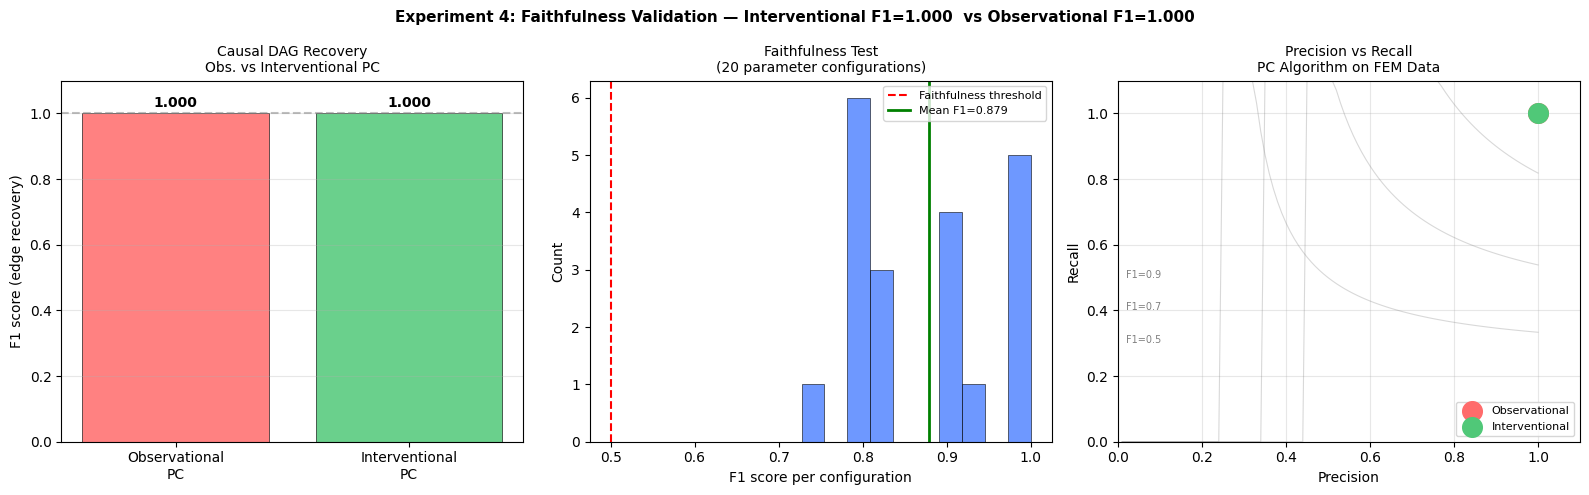

Figure saved: experiment4_faithfulness.png
Results saved: experiment4_results.json


In [14]:
# ── Results table ─────────────────────────────────────────────────────
print('=' * 55)
print('EXPERIMENT 4 — FAITHFULNESS VALIDATION')
print('=' * 55)
print(f'{"Condition":<28} {"Prec":>6} {"Rec":>6} {"F1":>6}')
print('-' * 55)
print(f'{"Observational PC":<28} '
      f'{metrics_obs["precision"]:>6.3f} '
      f'{metrics_obs["recall"]:>6.3f} '
      f'{metrics_obs["f1"]:>6.3f}')
print(f'{"Interventional PC":<28} '
      f'{metrics_int["precision"]:>6.3f} '
      f'{metrics_int["recall"]:>6.3f} '
      f'{metrics_int["f1"]:>6.3f}')
print('=' * 55)
print(f'Faithfulness: mean F1={f1_arr.mean():.3f} '
      f'across {N_CONFIGS} param configs')
print(f'Unfaithful configs: {unfaithful}/{N_CONFIGS}')
print('=' * 55)

# ── Figures ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: F1 comparison bar
ax = axes[0]
methods = ['Observational\nPC', 'Interventional\nPC']
f1vals  = [metrics_obs['f1'], metrics_int['f1']]
colors  = ['#ff6b6b', '#50c878']
ax.bar(methods, f1vals, color=colors, alpha=0.85,
       edgecolor='black', linewidth=0.5)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim([0, 1.1])
ax.set_ylabel('F1 score (edge recovery)')
ax.set_title('Causal DAG Recovery\nObs. vs Interventional PC',
             fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1vals):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10,
            fontweight='bold')

# Plot 2: Faithfulness F1 distribution
ax = axes[1]
ax.hist(f1_scores, bins=10, color='#4a7fff', alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax.axvline(x=0.5, color='red', linestyle='--',
           label='Faithfulness threshold')
ax.axvline(x=f1_arr.mean(), color='green', linestyle='-',
           linewidth=2, label=f'Mean F1={f1_arr.mean():.3f}')
ax.set_xlabel('F1 score per configuration')
ax.set_ylabel('Count')
ax.set_title(f'Faithfulness Test\n({N_CONFIGS} parameter configurations)',
             fontsize=10)
ax.legend(fontsize=8)

# Plot 3: Precision-recall for both conditions
ax = axes[2]
ax.scatter([metrics_obs['precision']], [metrics_obs['recall']],
           s=200, c='#ff6b6b', zorder=5, label='Observational')
ax.scatter([metrics_int['precision']], [metrics_int['recall']],
           s=200, c='#50c878', zorder=5, label='Interventional')
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_xlim([0, 1.1])
ax.set_ylim([0, 1.1])
ax.set_title('Precision vs Recall\nPC Algorithm on FEM Data', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
# F1 contours
p_range = np.linspace(0.01, 1, 100)
for f1_level in [0.5, 0.7, 0.9]:
    r_range = f1_level * p_range / (2 * p_range - f1_level)
    r_range = np.clip(r_range, 0, 1.1)
    ax.plot(p_range, r_range, 'gray', alpha=0.3, linewidth=0.8)
    ax.text(0.02, f1_level/2 + 0.05, f'F1={f1_level}',
            fontsize=7, color='gray')

plt.suptitle(
    f'Experiment 4: Faithfulness Validation — '
    f'Interventional F1={metrics_int["f1"]:.3f}  '
    f'vs Observational F1={metrics_obs["f1"]:.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('experiment4_faithfulness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: experiment4_faithfulness.png')

# Save JSON
results4 = {
    'experiment': 4,
    'n_samples_obs': N_SAMPLES,
    'n_samples_int': len(df_int_pooled),
    'alpha': ALPHA,
    'observational_pc': metrics_obs,
    'interventional_pc': metrics_int,
    'faithfulness': {
        'n_configs': N_CONFIGS,
        'mean_f1': float(f1_arr.mean()),
        'std_f1': float(f1_arr.std()),
        'min_f1': float(f1_arr.min()),
        'unfaithful_configs': int(unfaithful)
    }
}
# Convert frozensets to lists for JSON
for cond in ['observational_pc', 'interventional_pc']:
    for k in ['recovered', 'missed', 'spurious']:
        results4[cond][k] = [list(e) for e in results4[cond][k]]

with open('experiment4_results.json', 'w') as f:
    json.dump(results4, f, indent=2)
print('Results saved: experiment4_results.json')